# Chapter 5 Figures

Generates the four figures referenced in `DescripcionDataset.tex`, using only data that's already been processed. Run this notebook, then upload the resulting PNGs into your Overleaf project's `Imagenes/` folder. The filenames already match exactly what the LaTeX file expects, so no LaTeX edits are needed.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "liverrisk" / "features.py").exists():
            return p
    raise RuntimeError("Could not locate repo root (liverrisk/features.py not found)")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROCESSED_DIR = REPO_ROOT / "liverrisk" / "data" / "processed"
RAW_DIR = REPO_ROOT / "liverrisk" / "data" / "raw"

# Output folder: images are saved here, matching the filenames the LaTeX
# file expects. Upload the contents of this folder directly into your
# Overleaf project's Imagenes/ folder.
OUTPUT_DIR = REPO_ROOT / "chapter5_figures"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Figures will be saved to:", OUTPUT_DIR)

Figures will be saved to: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\chapter5_figures


In [3]:
# Load processed features and the raw training data (for T2DM/comorbidity coding)
X_hep = pd.read_parquet(PROCESSED_DIR / "hep_X.parquet")
raw_train = pd.read_csv(RAW_DIR / "train.csv")

with open(PROCESSED_DIR / "hep_y.pkl", "rb") as f:
    import pickle
    hep_payload = pickle.load(f)
hep_event = hep_payload["event"]

print("X_hep shape:", X_hep.shape)
print("hepatic events:", hep_event.sum(), "/", len(hep_event))

X_hep shape: (1253, 255)
hepatic events: 47 / 1253


## Figure 1: `fig_distributions_baseline.png`

Builds a four panel plot showing the distribution of baseline age, BMI, ALT, and AST across the training cohort.

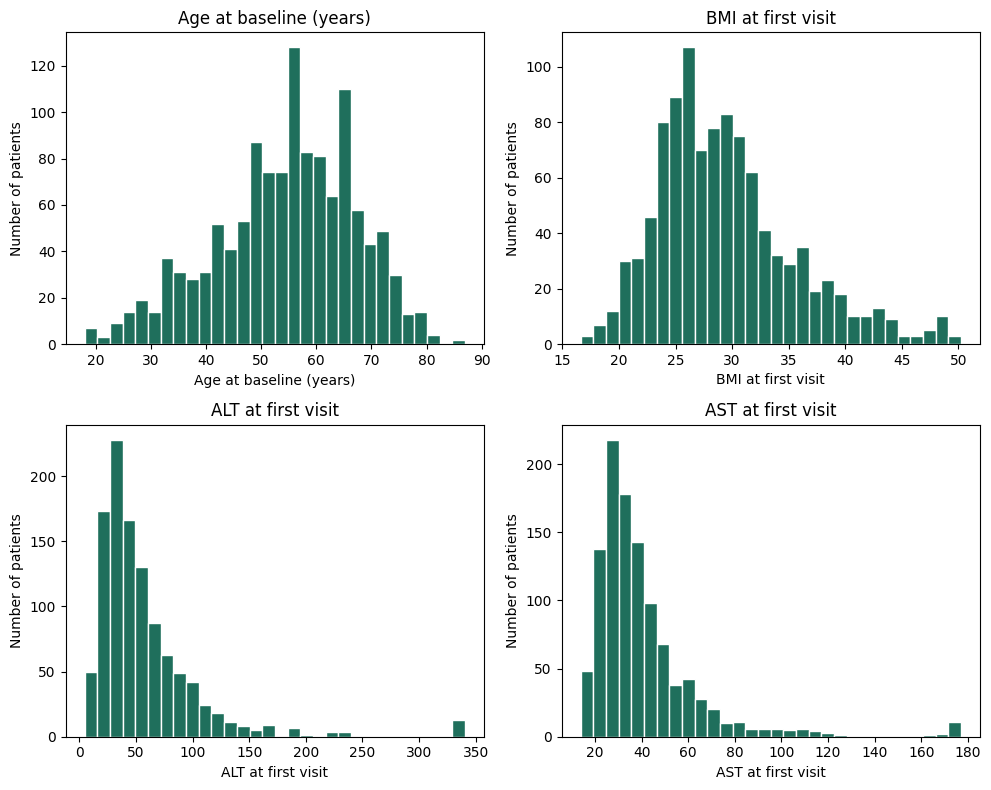

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

panels = [
    ("age_baseline", "Age at baseline (years)"),
    ("BMI__first", "BMI at first visit"),
    ("alt__first", "ALT at first visit"),
    ("ast__first", "AST at first visit"),
]

for ax, (col, label) in zip(axes.flat, panels):
    if col in X_hep.columns:
        data = X_hep[col].dropna()
        ax.hist(data, bins=30, color="#1F6F5C", edgecolor="white")
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel("Number of patients")
    else:
        ax.set_title(f"Column '{col}' not found -- check exact name in X_hep.columns")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_distributions_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: `fig_target_distribution.png`

Plots two bar charts side by side: how many patients had a hepatic event versus none, and how many patients died, were censored alive, or have an unknown status.

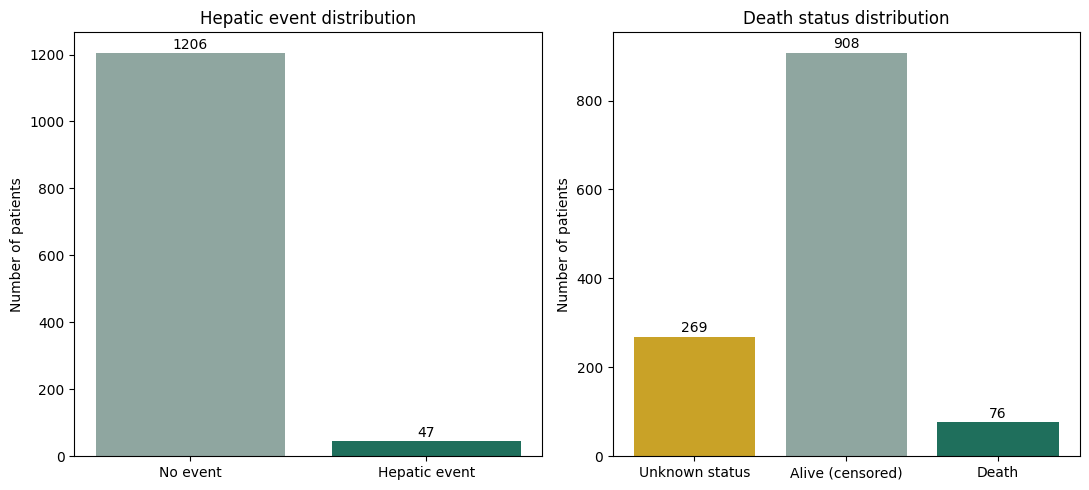

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel 1: hepatic event vs no event
hep_counts = pd.Series(hep_event).value_counts().sort_index()
axes[0].bar(["No event", "Hepatic event"], hep_counts.values, color=["#8FA6A0", "#1F6F5C"])
axes[0].set_title("Hepatic event distribution")
axes[0].set_ylabel("Number of patients")
for i, v in enumerate(hep_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center")

# Panel 2: death status (deceased / alive-censored / unknown)
death_col = raw_train["death"]
death_labels = ["Unknown status", "Alive (censored)", "Death"]
death_counts = [death_col.isna().sum(), (death_col == 0).sum(), (death_col == 1).sum()]
axes[1].bar(death_labels, death_counts, color=["#C9A227", "#8FA6A0", "#1F6F5C"])
axes[1].set_title("Death status distribution")
axes[1].set_ylabel("Number of patients")
for i, v in enumerate(death_counts):
    axes[1].text(i, v + 10, str(v), ha="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: `fig_missingness_nit.png`

For each of the three non-invasive tests (FibroTest, Aixplorer, FibroScan), checks whether the patient has at least one recorded value across any visit, and plots what fraction of the cohort that covers.

{'FibroTest': np.float64(70.86991221069432), 'Aixplorer': np.float64(64.72466081404629), 'FibroScan': np.float64(100.0)}


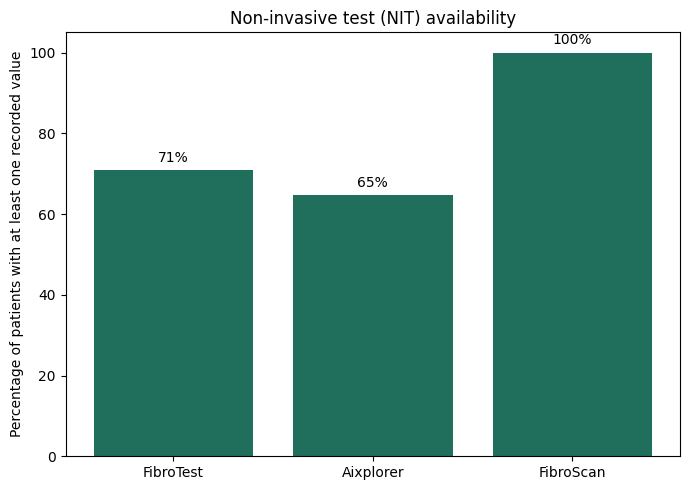

In [6]:
import re

def visit_cols(columns, base):
    return [c for c in columns if re.fullmatch(re.escape(base) + r"_v\d+", c)]

nit_bases = {
    "FibroTest": "fibrotest_BM_2",
    "Aixplorer": "aixp_aix_result_BM_3",
    "FibroScan": "fibs_stiffness_med_BM_1",
}

availability_pct = {}
for label, base in nit_bases.items():
    cols = visit_cols(raw_train.columns, base)
    has_any = raw_train[cols].notna().any(axis=1)
    availability_pct[label] = has_any.mean() * 100

print(availability_pct)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(availability_pct.keys(), availability_pct.values(), color="#1F6F5C")
ax.set_ylabel("Percentage of patients with at least one recorded value")
ax.set_title("Non-invasive test (NIT) availability")
ax.set_ylim(0, 105)
for bar, val in zip(bars, availability_pct.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f"{val:.0f}%", ha="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_missingness_nit.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 4: `fig_missingness_comorbidity.png`

Plots a stacked bar chart showing how the four comorbidity fields (T2DM, Hypertension, Dyslipidaemia, bariatric surgery) are coded, since they all share the same 0/1/2 pattern for no, yes, and unknown.

                   No (0)  Yes (1)  Unknown (2)
T2DM                  522      368           97
Hypertension          460      426           99
Dyslipidaemia         491      378          117
bariatric_surgery     827       72           78


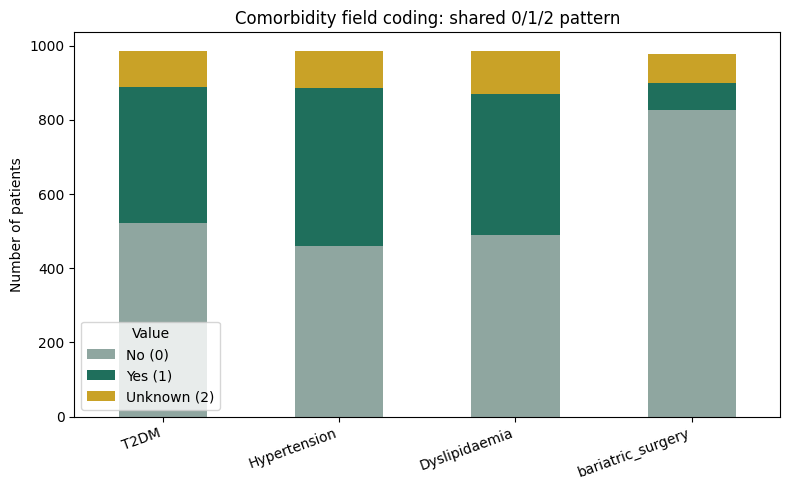

In [7]:
comorbidity_cols = ["T2DM", "Hypertension", "Dyslipidaemia", "bariatric_surgery"]

counts_by_field = {}
for col in comorbidity_cols:
    counts_by_field[col] = raw_train[col].value_counts().reindex([0.0, 1.0, 2.0], fill_value=0)

counts_df = pd.DataFrame(counts_by_field).T
counts_df.columns = ["No (0)", "Yes (1)", "Unknown (2)"]
print(counts_df)

fig, ax = plt.subplots(figsize=(8, 5))
counts_df.plot(kind="bar", stacked=True, ax=ax, color=["#8FA6A0", "#1F6F5C", "#C9A227"])
ax.set_ylabel("Number of patients")
ax.set_title("Comorbidity field coding: shared 0/1/2 pattern")
ax.legend(title="Value")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_missingness_comorbidity.png", dpi=150, bbox_inches="tight")
plt.show()

## Done

All four PNG files are now saved in the `chapter5_figures/` folder at your repo root. Upload them directly into your Overleaf project's `Imagenes/` folder; the filenames already match the LaTeX `\includegraphics` calls exactly, so no LaTeX changes are needed.